# Figure 4 — Updated (`figure_4_updated.ipynb`)

**Source:** mirrors `Figures_notebook/Figure4.ipynb` — SCP295 (Schiebinger 2019) MEF → iPSC reprogramming, branch-separated scJDO on a FactorAnalysis (30-D) latent space.

**Status of locked figure:** `Figure4_SCP295_locked.pdf` is the approved version. This notebook regenerates an updated PDF (`Figure4_updated.pdf`) with one targeted publication-readiness change:

> **Panel d (Stromal archetypes) — make the absence of A1↔A2 crossover visually undeniable.**
>
> - All four archetype panels (`c`, `c′`, `d`, `f`) now share the same Y-axis (`sharey`), so the reader compares activation curves on identical scale.
> - A1 and A2 are rendered thick (lw=3.1) in the foreground; A3–A5 sit as a desaturated backdrop. The handoff pair is no longer competing for visual weight.
> - On panels `c` / `c′` / `f`, the A1↔A2 crossover point is marked with a **gold star** plus an interpolated `t = …` label.
> - On panel `d`, a **shaded grey band** marks the expected-crossover pseudotime window inherited from IPS and MET, and a bold red callout reports `NO A1↔A2 crossover detected — min |A1 − A2| = …  (> 0 over full pseudotime)`.
> - Every archetype subtitle now carries `min|A1−A2|` and `tᶜ` (or `NO CROSSOVER`) so the quantitative signature lives in the panel header.

**Inputs / outputs.** Same as the source notebook — requires `scp295.h5ad` (path set in cell 2). Final figure is generated by the layout cell and saved as `Figure4_updated.pdf` and `Figure4_updated.png` directly into this `Manuscript/` directory. No other cells were modified.

**To regenerate:** run the entire notebook sequentially.


# Figure 4 — Reprogramming dynamics (Schiebinger 2019, SCP295)

Branch-separated scJDO drift fields on a fibroblast → iPSC reprogramming time course
(MEFs sampled every 0.5 day across 18 days, 24,999-cell stratified subsample).

Mirrors `Figure3_FA.ipynb`: FactorAnalysis latent space, per-lineage drift fields,
instability genes, and CollecTRI regulator inference. Differences from Figure 3:

* **Time** is the experimental day (no Palantir pseudotime needed — sampling is dense).
* **Embedding** is the published FLE (force-directed layout) instead of UMAP.
* **Lineages** are `IPS`, `Stromal`, `MET` — pluripotent success, terminal fibroblast
  failure, and mesenchymal-to-epithelial transition — taken from `cell_sets.gmt`.
* **Network** is mouse CollecTRI (organism='mouse').

In [1]:
#!pip install decoupler

In [2]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import scanpy as sc
import scjdo as sjd
from sklearn.decomposition import FactorAnalysis

mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family':  'DejaVu Sans',
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

# ── Dataset (SCP295 — Schiebinger 2019 reprogramming) ─────────────────────
# The h5ad cache is built once by `tools/build_scp295_h5ad.py` (see repo).
# 24,999 cells × 19,089 genes; obs has `day`, `day_norm`, `cell_set`; obsm has X_fle.
DATA_PATH = '/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/SCP295/scp295.h5ad'

# ── Pipeline config ────────────────────────────────────────────────────────
N_HVG          = 2000
N_LATENT       = 30      # FactorAnalysis components
FA_MAX_ITER    = 1000
N_ARCHETYPES   = 5
N_EPOCHS       = 5000
BIAS_STRENGTH  = 1.5
SEED           = 42
PROGENITOR_DAY = 1.0     # cells with day <= 1 treated as MEF starting state

BRANCHES       = ['IPS', 'Stromal', 'MET']
BRANCH_COLORS  = {'IPS': '#E63946', 'Stromal': '#457B9D', 'MET': '#2A9D8F'}
ARCH_COLORS    = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#8338EC']
K              = N_ARCHETYPES

# ── Output ─────────────────────────────────────────────────────────────────
# OUTDIR now points at the Manuscript/ folder itself: regenerated PDF/PNG
# land next to figure_4_updated.ipynb. Filenames are tagged `_updated`
# so they do NOT clobber the approved Figure4_SCP295_locked.pdf.
OUTDIR  = ''  # current working dir = Manuscript/
OUTSTEM = 'Figure4_updated'

print(f'scjdo v{sjd.__version__}')
print(f'Latent: FactorAnalysis ({N_LATENT}-D)  |  Time: experimental day  |  '
      f'Lineages: {" / ".join(BRANCHES)}')


scjdo v0.3.0
Latent: FactorAnalysis (30-D)  |  Time: experimental day  |  Lineages: IPS / Stromal / MET


In [3]:
# ── Step 1: Load cached SCP295 AnnData + define cell_fate labels ───────────
ad = sc.read(DATA_PATH)
print(f'Loaded: {ad.n_obs} cells × {ad.n_vars} genes')
print(f'day range: [{ad.obs["day"].min()}, {ad.obs["day"].max()}]  '
      f'({ad.obs["day"].nunique()} unique days)')
print('cell_set counts:'); print(ad.obs['cell_set'].value_counts().head(10).to_string())

# Build cell_fate column for the drift-field bias prior.
# Progenitor = MEF starting state (day <= PROGENITOR_DAY).
# Committed   = cells in one of the three terminal cell sets (day > PROGENITOR_DAY).
# Other       = uncommitted intermediates (not used as bias targets).
cs   = ad.obs['cell_set'].astype(str).values
day  = ad.obs['day'].astype(float).values
fate = np.where(day <= PROGENITOR_DAY, 'Progenitor',
         np.where(np.isin(cs, BRANCHES), cs, 'Other'))
ad.obs['cell_fate'] = pd.Categorical(fate,
    categories=['Progenitor'] + BRANCHES + ['Other'])
print('\ncell_fate distribution:')
print(ad.obs['cell_fate'].value_counts().to_string())

Loaded: 24999 cells × 19089 genes
day range: [0.0, 18.0]  (39 unique days)
cell_set counts:
cell_set
Other           10755
Stromal          4429
MET              3344
IPS              3326
TrophoLarger     2263
Epithelial        527
RG                169
OtherNeural       123
Neuron             53
Astrocyte           6

cell_fate distribution:
cell_fate
Other         11979
Stromal        4427
MET            3344
IPS            3326
Progenitor     1923


In [4]:
# ── Step 2: Preprocess + FactorAnalysis latent (mirrors Figure 3 cell 4) ──
ad.layers['raw_counts'] = ad.X.copy()
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)

sc.pp.highly_variable_genes(ad, n_top_genes=N_HVG, flavor='cell_ranger')

# Force-include canonical lineage markers regardless of HVG ranking. Low-detection
# markers like Pou5f1/Oct4 (~8% of cells) and Lin28a (~2%) miss the HVG cutoff in a
# heterogeneous reprogramming time course where the pluripotent minority appears only
# late, but they must enter the FA latent so the drift field can see them.
_MARKER_PANEL = [
    # Pluripotency / Yamanaka / naive
    'Pou5f1', 'Nanog', 'Sox2', 'Klf4', 'Myc', 'Esrrb', 'Zfp42', 'Dppa3', 'Tdgf1', 'Lin28a',
    # MET / epithelial
    'Cdh1', 'Epcam', 'Krt8', 'Krt18', 'Ocln',
    # EMT / mesenchymal / stromal
    'Snai1', 'Snai2', 'Zeb1', 'Zeb2', 'Twist1', 'Twist2', 'Vim', 'Cdkn1a', 'Cdkn2a',
]
_present  = [g for g in _MARKER_PANEL if g in ad.var_names]
_promoted = [g for g in _present if not bool(ad.var.loc[g, 'highly_variable'])]
ad.var.loc[_present, 'highly_variable'] = True
print(f'HVG: {int(ad.var["highly_variable"].sum())} genes '
      f'(+{len(_promoted)} markers force-included: {_promoted})')

import scipy.sparse as _sp
_hvg  = ad.var['highly_variable'].values
_Xhvg = ad[:, _hvg].X
_Xhvg = _Xhvg.toarray() if _sp.issparse(_Xhvg) else np.asarray(_Xhvg, dtype=np.float32)

fa = FactorAnalysis(n_components=N_LATENT, random_state=SEED, max_iter=FA_MAX_ITER)
ad.obsm['X_fa'] = fa.fit_transform(_Xhvg).astype('float32')

# scJDO reads gene loadings from varm['PCs'] regardless of the latent method;
# here it holds FactorAnalysis loadings (genes × factors), zero-padded for
# non-HVG genes so instability genes map back to gene space.
_loadings = np.zeros((ad.n_vars, N_LATENT), dtype=np.float32)
_loadings[_hvg] = fa.components_.T.astype('float32')
ad.varm['PCs'] = _loadings
del _Xhvg, _loadings

sc.pp.neighbors(ad, use_rep='X_fa')
print(f'FA: X_fa={ad.obsm["X_fa"].shape}, varm["PCs"]={ad.varm["PCs"].shape}')

HVG: 2007 genes (+7 markers force-included: ['Pou5f1', 'Lin28a', 'Ocln', 'Snai2', 'Twist2', 'Cdkn1a', 'Cdkn2a'])
FA: X_fa=(24999, 30), varm["PCs"]=(19089, 30)


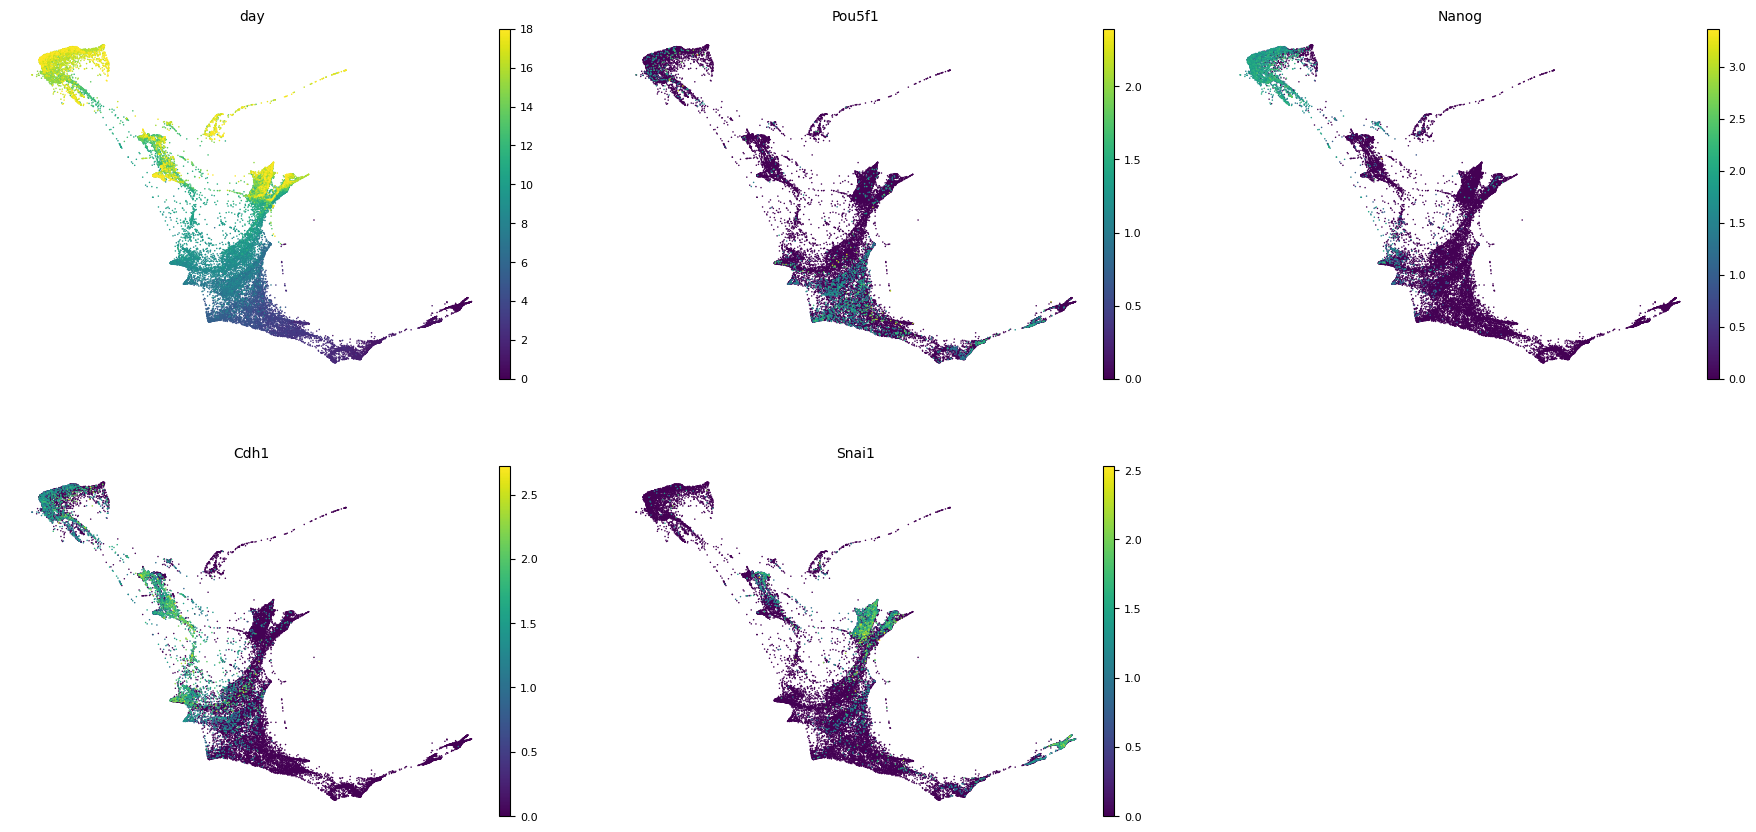

In [5]:
# ── Sanity check: lineage markers on the published FLE embedding ──────────
marker_panel = ['Pou5f1', 'Nanog', 'Cdh1', 'Snai1']      # pluripotency + MET + EMT
marker_panel = [g for g in marker_panel if g in ad.var_names]
sc.pl.embedding(ad, basis='fle', color=['day'] + marker_panel,
                cmap='viridis', frameon=False, ncols=3, show=True)

In [6]:
# ── Step 3: Build branch_masks for fit_drift_branches ──────────────────────
# Each branch trajectory = Progenitor cells + that terminal's cell-set members.
# Mirrors what palantir.presults.select_branch_cells produces in Figure 3.
prog_mask = (ad.obs['cell_fate'] == 'Progenitor').values
branch_masks = pd.DataFrame(index=ad.obs_names)
for b in BRANCHES:
    branch_masks[b] = prog_mask | (ad.obs['cell_fate'] == b).values
ad.obsm['branch_masks'] = branch_masks
print('Branch cell counts (progenitor + terminal members):')
for b in BRANCHES:
    n = int(branch_masks[b].sum())
    print(f'  {b:8s}: {n:>5d}  ({100*n/ad.n_obs:.0f}% of cells)')

Branch cell counts (progenitor + terminal members):
  IPS     :  5249  (21% of cells)
  Stromal :  6350  (25% of cells)
  MET     :  5267  (21% of cells)


In [7]:
# ── Step 4: Branch-separated scJDO drift fields (FA latent space) ─────────
# time_key='day_norm' — experimental day normalized to [0,1] (39 discrete steps,
# ~641 cells/day). Plays the role Palantir pseudotime played in Figure 3.
branch_models = sjd.tl.fit_drift_branches(
    ad,
    rep                = 'X_fa',
    branch_key         = 'branch_masks',
    branch_names       = BRANCHES,
    time_key           = 'day_norm',
    groupby            = 'cell_fate',
    progenitor_cluster = 'Progenitor',
    terminal_clusters  = {b: b for b in BRANCHES},
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    seed               = SEED,
)

print('\nscJDO branch results (FactorAnalysis latent space):')
for name in branch_models:
    key  = f'scjdo_{name}'
    res  = ad.uns[key]
    eig  = res['max_real_eig']
    peak = res['t_centers'][np.argmax(eig)]
    n_sens = int((eig > 0.05).sum())
    print(f"  {name:8s}: R²={res['r2']:.3f}, n={res['n_cells']}, "
          f"peak_t={peak:.3f}, max_eig={eig.max():.4f}, n_sensitive={n_sens}/{len(eig)}")

[bias] Progenitor 'Progenitor': 1923 cells, centroid computed in X_fa

Branch: IPS  (5249 cells)
  [bias] Terminal 'IPS': 3326 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: -0.012
Computing pseudotime-gradient velocity prior...
DriftField: 879,292 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 68.4950
Computing per-cell Jacobians...


Per-cell Jacobians:   0%|          | 0/42 [00:00<?, ?it/s]

Kernel-weighted temporal operator: grid_size=200, bandwidth='auto', adaptive=False
[kernel-windowing] selecting bandwidth from [0.01, 0.02, 0.03, 0.05, 0.08, 0.1]  (n_boot=20, n_eff_min=30.0)
  h=0.010  R=0.951  C=0.424  L=4.685  S=1.8875  n_eff_min(interior)=0.0
  h=0.020  R=0.972  C=0.414  L=2.698  S=1.0865  n_eff_min(interior)=0.0
  h=0.030  R=0.972  C=0.340  L=1.975  S=0.6533  n_eff_min(interior)=0.0
  h=0.050  R=0.958  C=0.257  L=2.356  S=0.5794  n_eff_min(interior)=5.5
  h=0.080  R=0.959  C=0.111  L=0.381  S=0.0407  n_eff_min(interior)=43.5
  h=0.100  R=0.996  C=0.120  L=0.378  S=0.0452  n_eff_min(interior)=161.9
[kernel-windowing] selected h*=0.1000  R=0.996  C=0.120  L=0.378  S=0.0452
Running archetype decomposition (semi-NMF)...
Done. R²=1.000 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=1.000  stored in adata.uns['scjdo_IPS']

Branch: Stromal  (6350 cells)
  [bias] Terminal 'Stromal': 4427 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.

...

Kernel-weighted temporal operator: grid_size=200, bandwidth='auto', adaptive=False
[kernel-windowing] selecting bandwidth from [0.01, 0.02, 0.03, 0.05, 0.08, 0.1]  (n_boot=20, n_eff_min=30.0)
  h=0.010  R=0.831  C=0.267  L=13.118  S=2.9088  n_eff_min(interior)=0.0
  h=0.020  R=0.833  C=0.250  L=1.320  S=0.2748  n_eff_min(interior)=0.0
  h=0.030  R=0.910  C=0.215  L=1.236  S=0.2419  n_eff_min(interior)=2.2
  h=0.050  R=0.992  C=0.200  L=1.128  S=0.2239  n_eff_min(interior)=5.6
  h=0.080  R=0.998  C=0.180  L=0.994  S=0.1783  n_eff_min(interior)=101.7
  h=0.100  R=0.999  C=0.164  L=0.979  S=0.1606  n_eff_min(interior)=713.4
[kernel-windowing] selected h*=0.0800  R=0.998  C=0.180  L=0.994  S=0.1783
Running archetype decomposition (semi-NMF)...
Done. R²=1.000 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=1.000  stored in adata.uns['scjdo_Stromal']

Branch: MET  (5267 cells)
  [bias] Terminal 'MET': 3344 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.02

Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 61.7475
Computing per-cell Jacobians...


Per-cell Jacobians:   0%|          | 0/42 [00:00<?, ?it/s]

Kernel-weighted temporal operator: grid_size=200, bandwidth='auto', adaptive=False
[kernel-windowing] selecting bandwidth from [0.01, 0.02, 0.03, 0.05, 0.08, 0.1]  (n_boot=20, n_eff_min=30.0)
  h=0.010  R=0.879  C=1.645  L=15.749  S=22.7626  n_eff_min(interior)=0.0
  h=0.020  R=0.891  C=1.645  L=9.843  S=14.4326  n_eff_min(interior)=0.0
  h=0.030  R=0.887  C=1.637  L=7.428  S=10.7867  n_eff_min(interior)=0.0
  h=0.050  R=0.909  C=1.613  L=7.484  S=10.9687  n_eff_min(interior)=2.5
  h=0.080  R=0.932  C=1.403  L=10.344  S=13.5242  n_eff_min(interior)=5.2
  h=0.100  R=0.957  C=0.885  L=10.902  S=9.2317  n_eff_min(interior)=19.8
[kernel-windowing] selected h*=0.0100  R=0.879  C=1.645  L=15.749  S=22.7626
Running archetype decomposition (semi-NMF)...
Done. R²=0.996 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=0.996  stored in adata.uns['scjdo_MET']

Branch results stored: ['scjdo_IPS', 'scjdo_Stromal', 'scjdo_MET']

scJDO branch results (FactorAnalysis latent space):
  IPS   

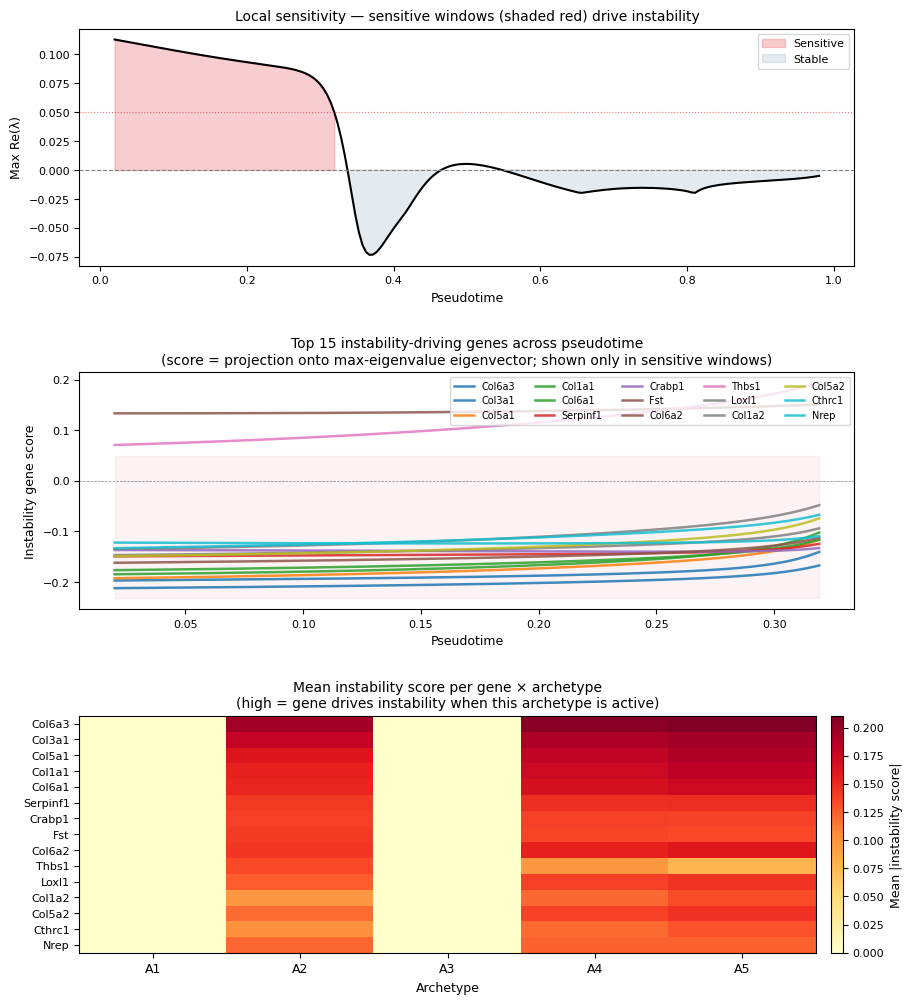

 rank     gene  mean_instability_score  peak_pseudotime primary_archetype
    1   Col6a3                  0.1583            0.020                A4
    2   Col3a1                  0.1488            0.020                A4
    3   Col5a1                  0.1355            0.020                A4
    4   Col1a1                  0.1335            0.020                A4
    5   Col6a1                  0.1308            0.020                A4
    6 Serpinf1                  0.1265            0.020                A4
    7   Crabp1                  0.1201            0.256                A2
    8      Fst                  0.1175            0.319                A2
    9   Col6a2                  0.1174            0.020                A4
   10    Thbs1                  0.1057            0.319                A2
   11    Loxl1                  0.1039            0.020                A4
   12   Col1a2                  0.1015            0.020                A4
   13   Col5a2                  0.1007

2026-05-31 18:49:13 | [INFO] maxp pruned
2026-05-31 18:49:13 | [INFO] cmap pruned
2026-05-31 18:49:13 | [INFO] kern dropped
2026-05-31 18:49:13 | [INFO] post pruned
2026-05-31 18:49:13 | [INFO] FFTM dropped
2026-05-31 18:49:13 | [INFO] GPOS pruned
2026-05-31 18:49:13 | [INFO] GSUB pruned
2026-05-31 18:49:13 | [INFO] glyf pruned
2026-05-31 18:49:13 | [INFO] Added gid0 to subset
2026-05-31 18:49:13 | [INFO] Added first four glyphs to subset
2026-05-31 18:49:13 | [INFO] Closing glyph list over 'MATH': 60 glyphs before
2026-05-31 18:49:13 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'G', 'I', 'L', 'M', 'P', 'R', 'S', 'T', 'W', 'a', 'b', 'bar', 'c', 'd', 'e', 'eight', 'emdash', 'equal', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'j', 'k', 'l', 'lambda', 'm', 'minus', 'multiply', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'semicolon', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'x', 'y', 'zero']
2026-05-31 18:4

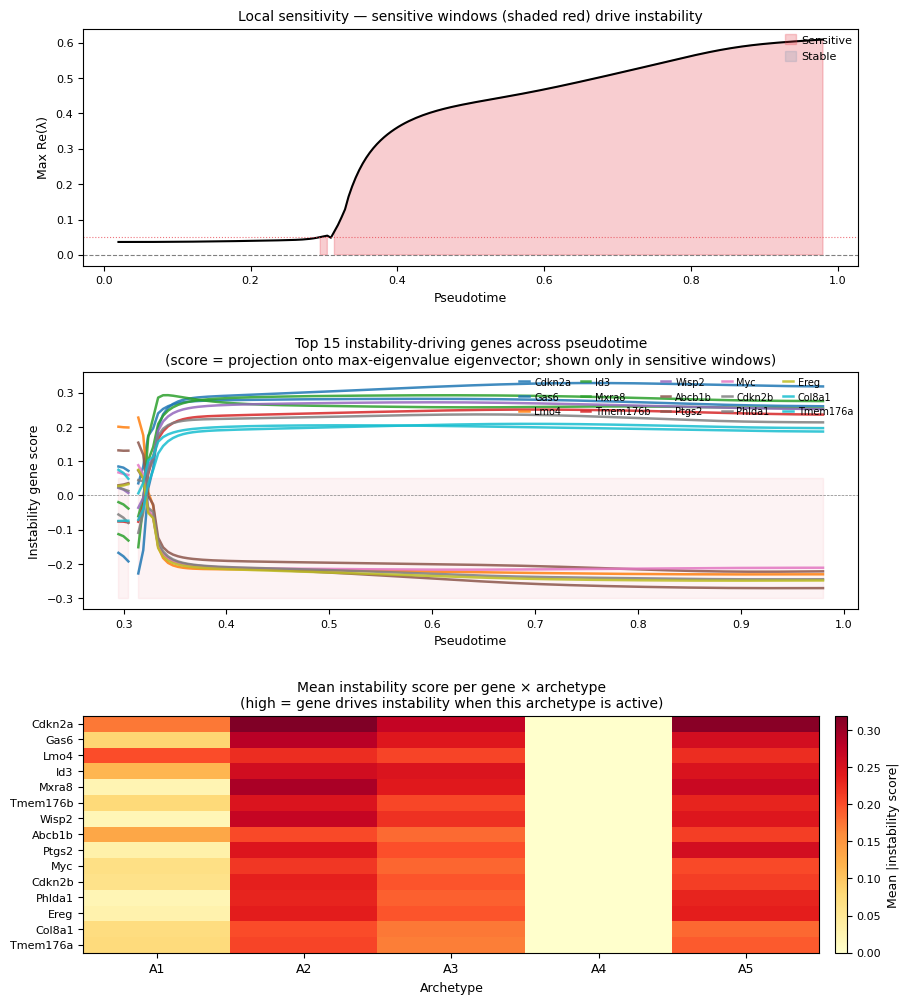

 rank     gene  mean_instability_score  peak_pseudotime primary_archetype
    1   Cdkn2a                  0.2504            0.753                A2
    2     Gas6                  0.2133            0.589                A2
    3     Lmo4                  0.2091            0.908                A5
    4      Id3                  0.2056            0.343                A3
    5    Mxra8                  0.1962            0.613                A2
    6 Tmem176b                  0.1884            0.700                A2
    7    Wisp2                  0.1877            0.599                A2
    8   Abcb1b                  0.1747            0.917                A5
    9    Ptgs2                  0.1690            0.946                A5
   10      Myc                  0.1678            0.628                A2
   11   Cdkn2b                  0.1645            0.647                A2
   12   Phlda1                  0.1640            0.932                A5
   13     Ereg                  0.1620

2026-05-31 18:49:21 | [INFO] maxp pruned
2026-05-31 18:49:21 | [INFO] cmap pruned
2026-05-31 18:49:21 | [INFO] kern dropped
2026-05-31 18:49:21 | [INFO] post pruned
2026-05-31 18:49:21 | [INFO] FFTM dropped
2026-05-31 18:49:21 | [INFO] GPOS pruned
2026-05-31 18:49:21 | [INFO] GSUB pruned
2026-05-31 18:49:21 | [INFO] glyf pruned
2026-05-31 18:49:21 | [INFO] Added gid0 to subset
2026-05-31 18:49:21 | [INFO] Added first four glyphs to subset
2026-05-31 18:49:21 | [INFO] Closing glyph list over 'MATH': 60 glyphs before
2026-05-31 18:49:21 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'G', 'H', 'I', 'L', 'M', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'bar', 'c', 'd', 'e', 'eight', 'emdash', 'equal', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'j', 'k', 'l', 'lambda', 'm', 'minus', 'multiply', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'semicolon', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'x', 'y', 'zero']
2026-05-31 18:4

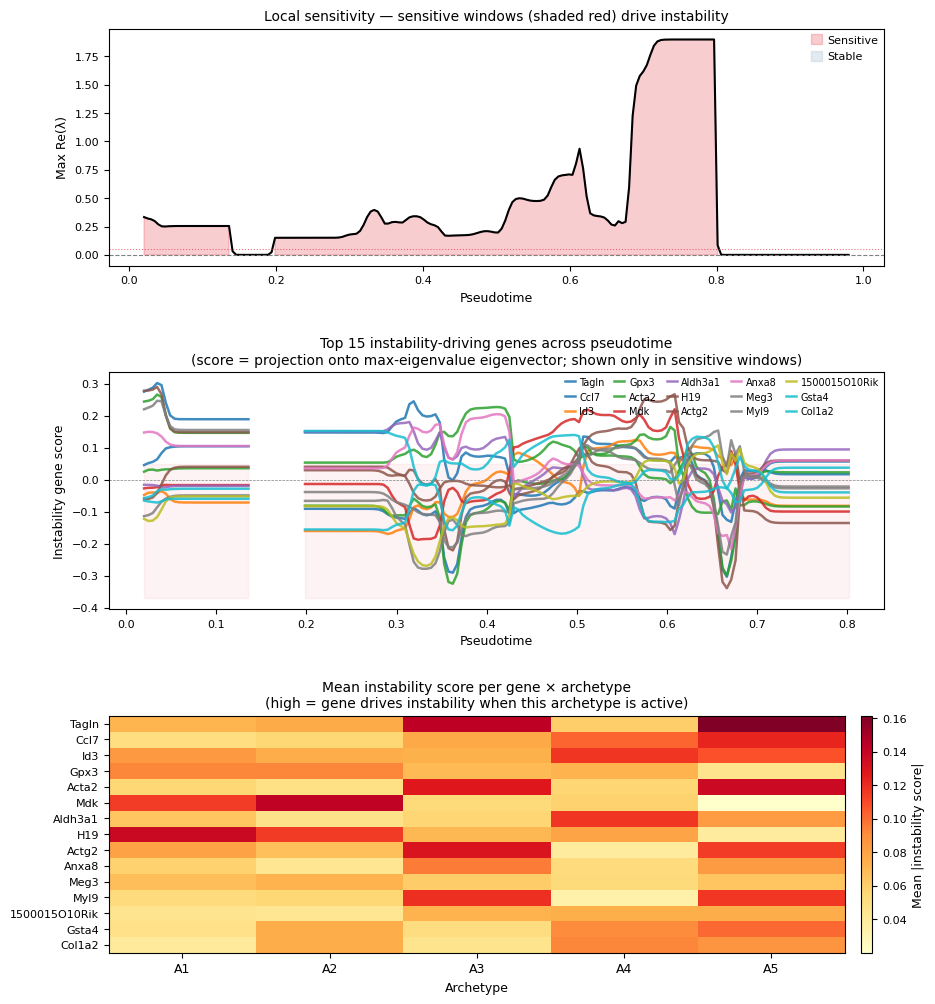

 rank          gene  mean_instability_score  peak_pseudotime primary_archetype
    1         Tagln                  0.0979            0.666                A5
    2          Ccl7                  0.0874            0.319                A5
    3           Id3                  0.0862            0.290                A5
    4          Gpx3                  0.0841            0.411                A4
    5         Acta2                  0.0831            0.363                A5
    6           Mdk                  0.0809            0.609                A2
    7       Aldh3a1                  0.0780            0.314                A5
    8           H19                  0.0776            0.609                A2
    9         Actg2                  0.0776            0.666                A5
   10         Anxa8                  0.0764            0.671                A5
   11          Meg3                  0.0762            0.329                A5
   12          Myl9                  0.0757         

In [8]:
# ── Step 5: Instability genes + CollecTRI regulators per lineage ──────────
df_genes = {}
df_regs  = {}

_EMPTY_REGS = pd.DataFrame(columns=[
    'regulator', 'weighted_score', 'mean_instability',
    'enrichment_score', 'branch_specificity', 'peak_archetype',
    'db_confidence', 'n_targets', 'enrichment_pval', 'top_targets',
])

for name in branch_models:
    key      = f'scjdo_{name}'
    cell_idx = np.array(ad.uns[key]['branch_cells'])
    ad_b     = ad[cell_idx].copy()
    ad_b.uns[key] = ad.uns[key]

    table = sjd.pl.instability_genes(
        ad_b, key=key, n_genes=15,
        save=OUTDIR + f'instab_{name}.pdf',
    )
    df_genes[name] = table
    table.to_csv(OUTDIR + f'instability_genes_{name}.csv', index=False)

    reg_key = f'scjdo_regulators_{name}'
    try:
        df_reg = sjd.tl.infer_regulators(
            ad_b, key=key, organism='mouse', min_targets=1,
            n_top=15, key_added=reg_key, verbose=False,
        )
    except ValueError as e:
        print(f'  [{name}] infer_regulators: {e} — empty fallback')
        df_reg = _EMPTY_REGS.copy()
    df_regs[name] = df_reg
    df_reg.to_csv(OUTDIR + f'regulators_{name}.csv', index=False)

    top_genes = table['gene'].head(10).tolist() if len(table) else []
    top_regs  = df_reg['regulator'].head(10).tolist() if len(df_reg) else ['(none)']
    print(f'\n{name}:')
    print(f'  Top instab genes: {top_genes}')
    print(f'  Top regulators:   {top_regs}')

IPS_late subset: 19,871 cells (day >= 4.0)
cell_fate_late
Other_late         11417
Progenitor_late     5128
IPS_late            3326
[bias] Progenitor 'Progenitor_late': 5128 cells, centroid computed in X_fa

Branch: IPS_late  (8454 cells)
  [bias] Terminal 'IPS_late': 3326 cells | bias_strength=1.5
  [bias] Alignment with prog→terminal axis: 0.184
Computing pseudotime-gradient velocity prior...
DriftField: 879,292 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 64.5730
Computing per-cell Jacobians...


Per-cell Jacobians:   0%|          | 0/67 [00:00<?, ?it/s]

Kernel-weighted temporal operator: grid_size=200, bandwidth='auto', adaptive=False
[kernel-windowing] selecting bandwidth from [0.01, 0.02, 0.03, 0.05, 0.08, 0.1]  (n_boot=20, n_eff_min=30.0)
  h=0.010  R=0.947  C=0.318  L=4.592  S=1.3816  n_eff_min(interior)=0.0
  h=0.020  R=0.951  C=0.297  L=5.206  S=1.4709  n_eff_min(interior)=4.3
  h=0.030  R=0.957  C=0.130  L=1.886  S=0.2351  n_eff_min(interior)=11.7
  h=0.050  R=0.987  C=0.047  L=0.533  S=0.0245  n_eff_min(interior)=136.4
  h=0.080  R=0.997  C=0.048  L=0.394  S=0.0190  n_eff_min(interior)=725.8
  h=0.100  R=0.998  C=0.051  L=0.313  S=0.0158  n_eff_min(interior)=1491.5
[kernel-windowing] selected h*=0.0500  R=0.987  C=0.047  L=0.533  S=0.0245
Running archetype decomposition (semi-NMF)...
Done. R²=1.000 | Archetypes stored in adata.uns['scjdo_branch']
  Done. R²=1.000  stored in adata.uns['scjdo_IPS_late']

Branch results stored: ['scjdo_IPS_late']


2026-05-31 19:06:07 | [INFO] maxp pruned
2026-05-31 19:06:07 | [INFO] cmap pruned
2026-05-31 19:06:07 | [INFO] kern dropped
2026-05-31 19:06:07 | [INFO] post pruned
2026-05-31 19:06:07 | [INFO] FFTM dropped
2026-05-31 19:06:07 | [INFO] GPOS pruned
2026-05-31 19:06:07 | [INFO] GSUB pruned
2026-05-31 19:06:07 | [INFO] glyf pruned
2026-05-31 19:06:07 | [INFO] Added gid0 to subset
2026-05-31 19:06:07 | [INFO] Added first four glyphs to subset
2026-05-31 19:06:07 | [INFO] Closing glyph list over 'MATH': 61 glyphs before
2026-05-31 19:06:07 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'H', 'I', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'a', 'b', 'bar', 'c', 'd', 'e', 'eight', 'emdash', 'equal', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'j', 'k', 'l', 'lambda', 'm', 'minus', 'multiply', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'semicolon', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'x', 'y', 'zero']
2026-05-31 19

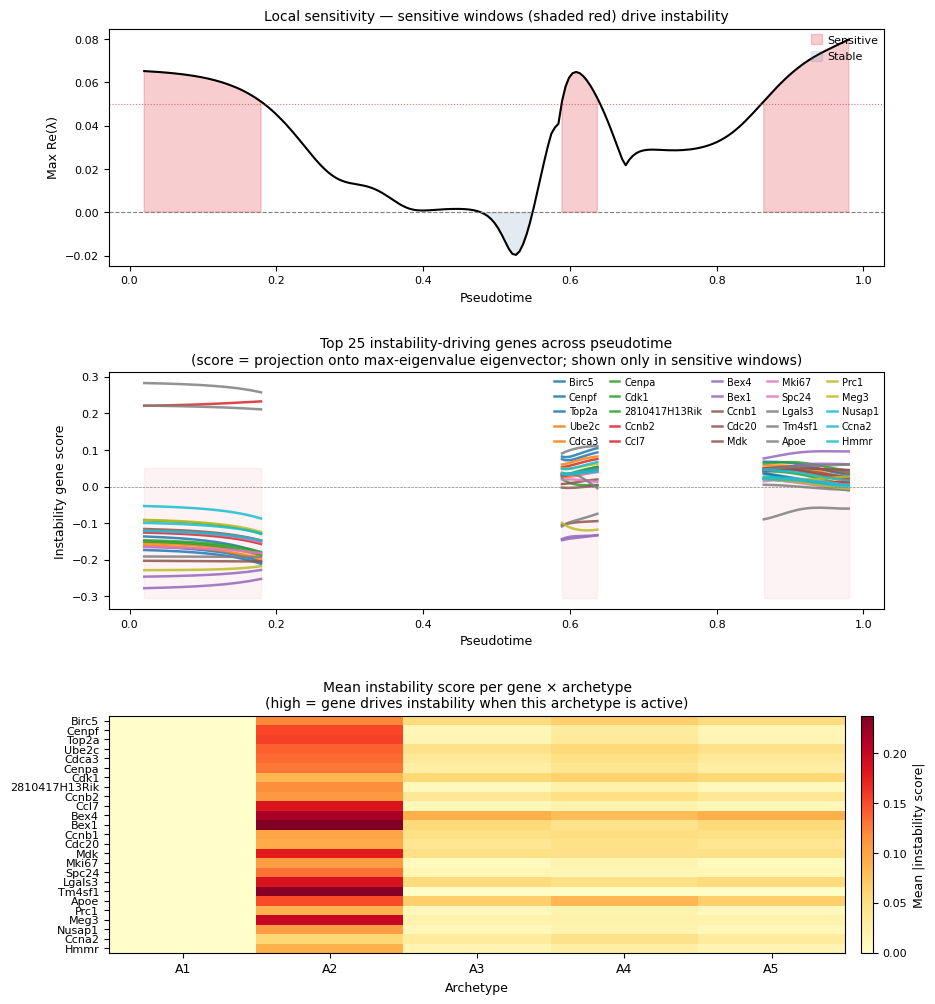

 rank          gene  mean_instability_score  peak_pseudotime primary_archetype
    1         Birc5                  0.1654            0.179                A2
    2         Cenpf                  0.1622            0.179                A2
    3         Top2a                  0.1604            0.179                A2
    4         Ube2c                  0.1580            0.179                A2
    5         Cdca3                  0.1516            0.179                A2
    6         Cenpa                  0.1479            0.179                A2
    7          Cdk1                  0.1287            0.179                A2
    8 2810417H13Rik                  0.1287            0.179                A2
    9         Ccnb2                  0.1282            0.179                A2
   10          Ccl7                  0.1227            0.179                A2
   11          Bex4                  0.1211            0.020                A2
   12          Bex1                  0.1201         

In [9]:
# ── Step 5b: IPS_late — late-day window to surface the Yamanaka network ───
# Pluripotency markers fire only in the small minority of cells that reach iPSC
# state; averaging over the full 18-day trajectory dilutes them with ~90% of
# cells where they are zero. Restricting to day >= MIN_DAY_LATE concentrates the
# drift field on the window where Sox2/Klf4/Nanog dynamics matter and (in this
# dataset) endogenous loci begin to activate.
#
# Note: Pou5f1 detection actually drops late (the Dox-induced OSKM transgene is
# OFF after D8; endogenous Pou5f1 only activates in the few % that complete
# reprogramming). Pou5f1 still surfaces as a *regulator* because its targets in
# CollecTRI are now dynamically unstable in this window, even when the TF itself
# is detected in only a small subset of cells.
MIN_DAY_LATE = 4.0

late_mask = (ad.obs['day'] >= MIN_DAY_LATE).values
ad_late = ad[late_mask].copy()
day_l = ad_late.obs['day'].astype(float).values
cs_l  = ad_late.obs['cell_set'].astype(str).values
fate_late = np.where((day_l < 8) & (cs_l != 'IPS'), 'Progenitor_late',
            np.where(cs_l == 'IPS', 'IPS_late', 'Other_late'))
ad_late.obs['cell_fate_late'] = pd.Categorical(
    fate_late, categories=['Progenitor_late', 'IPS_late', 'Other_late'])
print(f'IPS_late subset: {ad_late.n_obs:,} cells (day >= {MIN_DAY_LATE})')
print(ad_late.obs['cell_fate_late'].value_counts().to_string())

prog_l = (ad_late.obs['cell_fate_late'] == 'Progenitor_late').values
ips_l  = (ad_late.obs['cell_fate_late'] == 'IPS_late').values
ad_late.obsm['branch_masks_late'] = pd.DataFrame(
    {'IPS_late': prog_l | ips_l}, index=ad_late.obs_names)

bm_late = sjd.tl.fit_drift_branches(
    ad_late,
    rep                = 'X_fa',
    branch_key         = 'branch_masks_late',
    branch_names       = ['IPS_late'],
    time_key           = 'day_norm',
    groupby            = 'cell_fate_late',
    progenitor_cluster = 'Progenitor_late',
    terminal_clusters  = {'IPS_late': 'IPS_late'},
    bias_strength      = BIAS_STRENGTH,
    n_archetypes       = N_ARCHETYPES,
    n_epochs           = N_EPOCHS,
    vel_scale          = 2.0,
    seed               = SEED,
)

# Make the IPS_late drift result visible from `ad.uns` too, so the downstream
# figure + summary cells can read every branch uniformly via `ad.uns[f'scjdo_{name}']`.
ad.uns['scjdo_IPS_late'] = ad_late.uns['scjdo_IPS_late']

# Instability + regulators on the IPS_late branch
key      = 'scjdo_IPS_late'
cell_idx = np.array(ad_late.uns[key]['branch_cells'])
ad_b     = ad_late[cell_idx].copy()
ad_b.uns[key]    = ad_late.uns[key]
ad_b.varm['PCs'] = ad.varm['PCs']            # share FA loadings

table = sjd.pl.instability_genes(
    ad_b, key=key, n_genes=25,
    save=OUTDIR + 'instab_IPS_late.pdf',
)
df_genes['IPS_late'] = table
table.to_csv(OUTDIR + 'instability_genes_IPS_late.csv', index=False)

try:
    df_reg = sjd.tl.infer_regulators(
        ad_b, key=key, organism='mouse', min_targets=1,
        n_top=20, key_added='scjdo_regulators_IPS_late', verbose=False,
    )
except ValueError as e:
    print(f'  [IPS_late] infer_regulators: {e} — empty fallback')
    df_reg = _EMPTY_REGS.copy()
df_regs['IPS_late'] = df_reg
df_reg.to_csv(OUTDIR + 'regulators_IPS_late.csv', index=False)

print(f'\nIPS_late top-10 instability genes: {table["gene"].head(10).tolist()}')
print(f'IPS_late top-10 regulators:       {df_reg["regulator"].head(10).tolist()}')

# Diagnostic: where do the Yamanaka / naive-pluripotency markers land?
print('\n--- Pluripotency marker positions in IPS_late ---')
for g in ['Pou5f1', 'Nanog', 'Sox2', 'Klf4', 'Myc',
          'Esrrb', 'Zfp42', 'Dppa3', 'Tdgf1', 'Lin28a']:
    rank = (int(table.loc[table['gene'] == g, 'rank'].iloc[0])
            if (table['gene'] == g).any() else None)
    as_tf = bool((df_reg['regulator'] == g).any())
    n_tg  = (df_reg['top_targets'].str.contains(rf'\b{g}\b', regex=True, na=False).sum()
             if len(df_reg) else 0)
    print(f'  {g:8s}  gene_rank: {str(rank) if rank else "—":<5}  '
          f'as_TF: {as_tf}   as_target_of_n_TFs: {n_tg}')

2026-05-31 19:06:16 | [INFO] maxp pruned
2026-05-31 19:06:16 | [INFO] cmap pruned
2026-05-31 19:06:16 | [INFO] kern dropped
2026-05-31 19:06:16 | [INFO] post pruned
2026-05-31 19:06:16 | [INFO] FFTM dropped
2026-05-31 19:06:16 | [INFO] GPOS pruned
2026-05-31 19:06:16 | [INFO] GSUB pruned
2026-05-31 19:06:16 | [INFO] glyf pruned
2026-05-31 19:06:16 | [INFO] Added gid0 to subset
2026-05-31 19:06:16 | [INFO] Added first four glyphs to subset
2026-05-31 19:06:16 | [INFO] Closing glyph list over 'GSUB': 76 glyphs before
2026-05-31 19:06:16 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'arrowboth', 'arrowright', 'b', 'bar', 'c', 'comma', 'd', 'e', 'eight', 'emdash', 'endash', 'equal', 'f', 'five', 'four', 'g', 'greater', 'greaterequal', 'h', 'hyphen', 'i', 'j', 'l', 'less', 'lessequal', 'm', 'minus', 'minute', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'periodcen

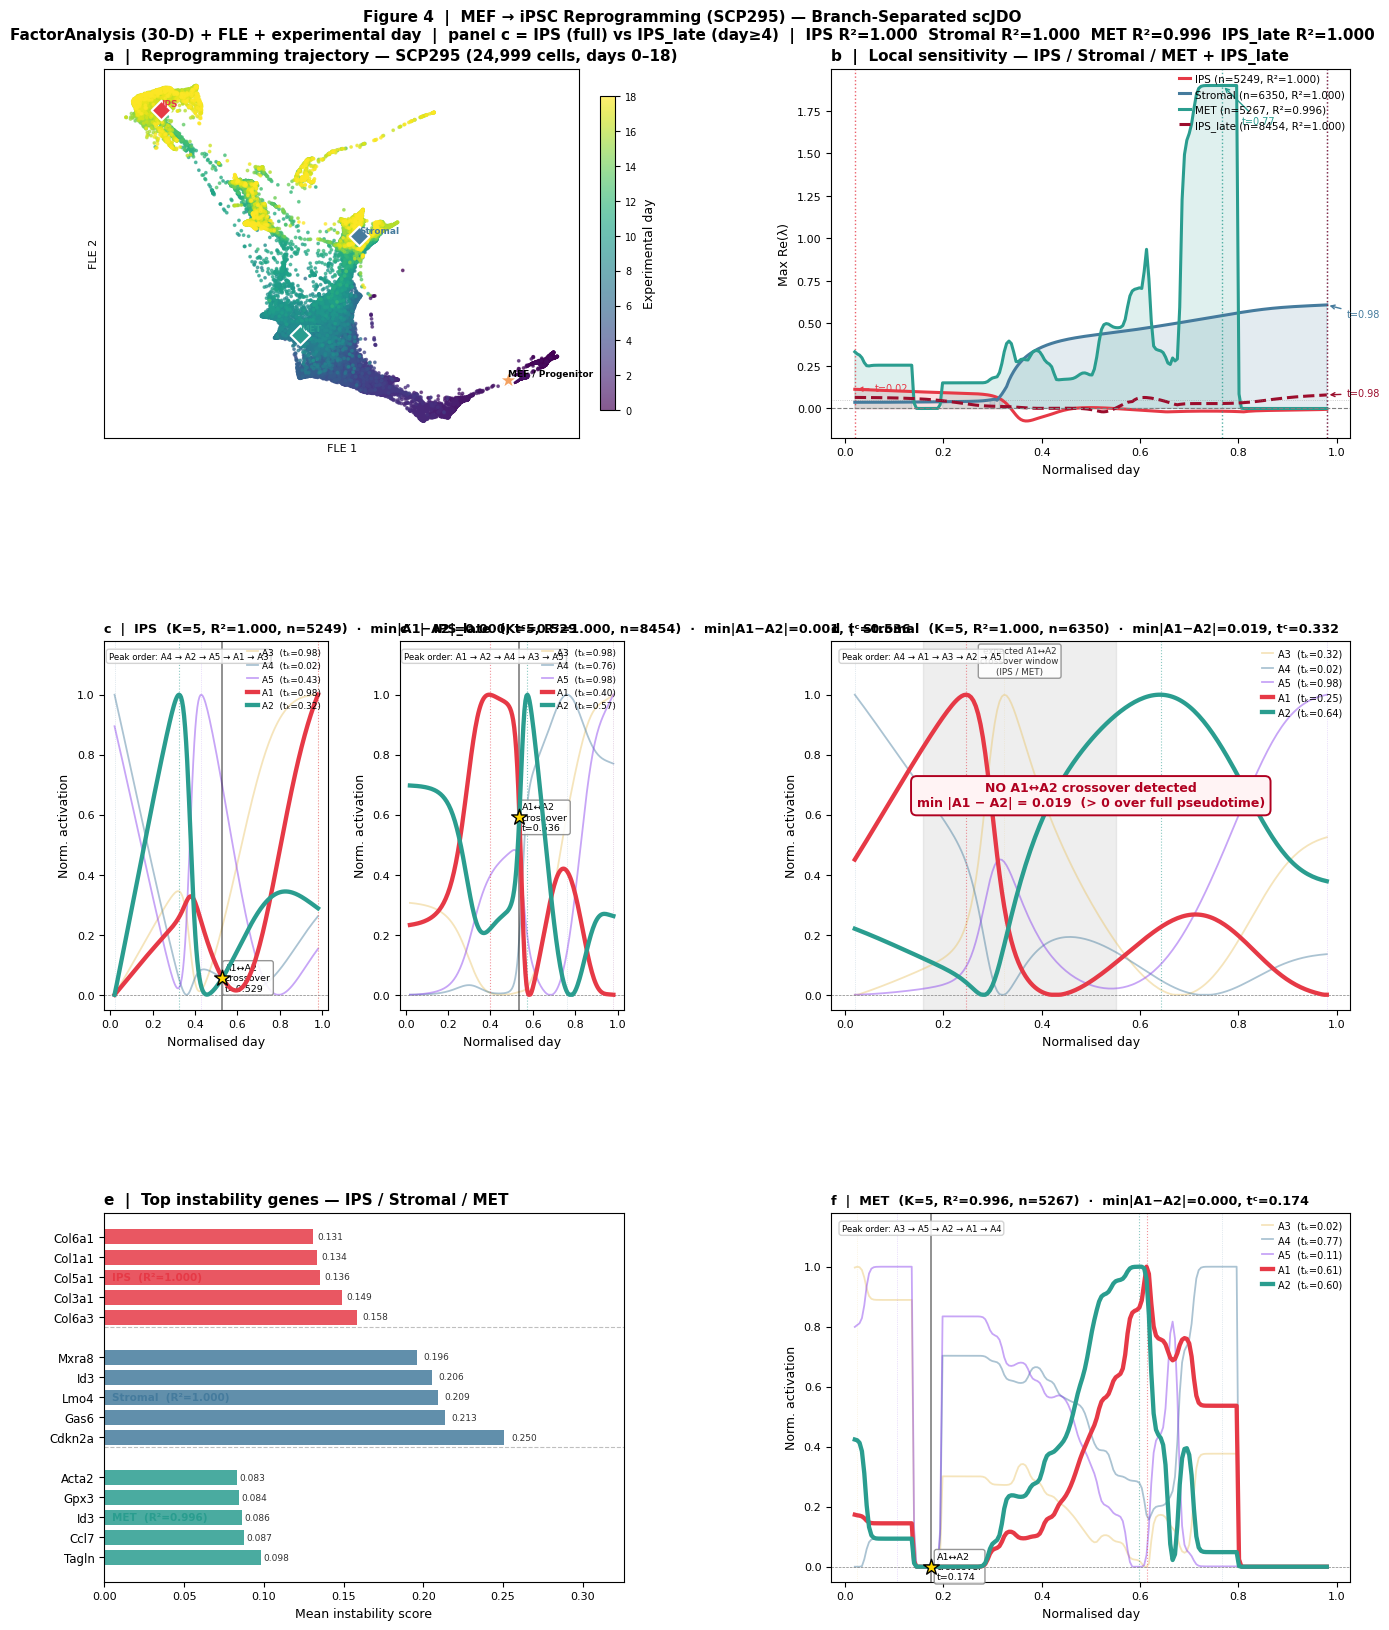

Saved: Figure4_updated.pdf / .png


In [10]:
# ── Figure 4 layout (UPDATED) — 3 rows × 2 cols ──────────────────────────
# (a) FLE + day                          (b) Sensitivity — IPS / Stromal / MET / IPS_late
# (c) IPS / IPS_late split panel         (d) Stromal archetypes  ← undeniable no-crossover
# (e) Instability genes                  (f) MET archetypes
#
# Publication-readiness fix vs the locked v: archetype panels (c, d, f) now share
# the same Y axis, A1 and A2 are rendered thick over a desaturated A3-A5 backdrop,
# the A1↔A2 crossover point is marked with a gold star on IPS and MET, and the
# Stromal panel carries a shaded `expected crossover window` plus a bold
# `NO A1↔A2 crossover` callout annotated with min |A1−A2|. Result: a reader sees
# the absence-of-handoff finding without having to overlay panels mentally.
IPS_LATE_COLOR = '#9B0D2C'
_HAS_LATE = ('scjdo_IPS_late' in ad.uns)

fig = plt.figure(figsize=(14, 17))
gs  = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.40,
                        left=0.08, right=0.97, top=0.94, bottom=0.05)
ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])

if _HAS_LATE:
    gs_c  = gs[1, 0].subgridspec(1, 2, wspace=0.32)
    ax_c1 = fig.add_subplot(gs_c[0, 0])
    ax_c2 = fig.add_subplot(gs_c[0, 1], sharey=ax_c1)
else:
    ax_c1 = fig.add_subplot(gs[1, 0])
    ax_c2 = None
ax_d  = fig.add_subplot(gs[1, 1], sharey=ax_c1)
ax_e, ax_f = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])
ax_f.sharey(ax_c1)  # all four archetype panels on identical y-scale

# ══════════════════════════════════════════════════════════════════════════
# Panel a: FLE coloured by experimental day + lineage centroids
# ══════════════════════════════════════════════════════════════════════════
fle = ad.obsm['X_fle']
day = ad.obs['day'].values
sc_img = ax_a.scatter(fle[:, 0], fle[:, 1], c=day,
                      cmap='viridis', s=3, alpha=0.65, rasterized=True)
cb = plt.colorbar(sc_img, ax=ax_a, label='Experimental day',
                  fraction=0.046, pad=0.04, shrink=0.85)
cb.ax.tick_params(labelsize=7)

prog_mask = (ad.obs['cell_fate'] == 'Progenitor').values
if prog_mask.sum() > 0:
    cx, cy = fle[prog_mask, 0].mean(), fle[prog_mask, 1].mean()
    ax_a.scatter(cx, cy, marker='*', s=220, color='#F4A261',
                 edgecolors='white', linewidths=1.5, zorder=5)
    ax_a.text(cx, cy + 200, 'MEF / Progenitor',
              fontsize=6.5, fontweight='bold', color='black', zorder=6)
for branch, color in BRANCH_COLORS.items():
    mask = (ad.obs['cell_fate'] == branch).values
    if mask.sum() > 0:
        cx, cy = fle[mask, 0].mean(), fle[mask, 1].mean()
        ax_a.scatter(cx, cy, marker='D', s=100, color=color,
                     edgecolors='white', linewidths=1.5, zorder=5)
        ax_a.text(cx, cy + 200, branch,
                  fontsize=6.5, fontweight='bold', color=color, zorder=6)

ax_a.set_xlabel('FLE 1', fontsize=8); ax_a.set_ylabel('FLE 2', fontsize=8)
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_title(f'a  |  Reprogramming trajectory — SCP295 ({ad.n_obs:,} cells, days 0–18)',
               fontweight='bold', loc='left', fontsize=11)

# ══════════════════════════════════════════════════════════════════════════
# Panel b: Local sensitivity — main 3 lineages + IPS_late (if present)
# ══════════════════════════════════════════════════════════════════════════
_b_specs = [(n, BRANCH_COLORS[n], '-') for n in branch_models]
if _HAS_LATE:
    _b_specs += [('IPS_late', IPS_LATE_COLOR, '--')]
for name, color, ls in _b_specs:
    if f'scjdo_{name}' not in ad.uns:
        continue
    res    = ad.uns[f'scjdo_{name}']
    t, eig = res['t_centers'], res['max_real_eig']
    peak_i = int(np.argmax(eig))
    peak_t, peak_v = float(t[peak_i]), float(eig[peak_i])
    n      = res['n_cells']

    ax_b.plot(t, eig, color=color, lw=2.2, ls=ls,
              label=f'{name} (n={n}, R²={res["r2"]:.3f})')
    if ls == '-':
        ax_b.fill_between(t, eig, 0, where=(eig >= 0.05),
                          alpha=0.15, color=color)
    ax_b.axvline(peak_t, color=color, lw=1.0, ls=':', alpha=0.8)
    ax_b.annotate(f't={peak_t:.2f}', xy=(peak_t, peak_v),
                  xytext=(peak_t + 0.04, peak_v * 0.88),
                  arrowprops=dict(arrowstyle='->', color=color, lw=1.0),
                  fontsize=7, color=color)

ax_b.axhline(0,    color='gray', lw=0.8, ls='--')
ax_b.axhline(0.05, color='gray', lw=0.6, ls=':', alpha=0.5)
ax_b.set_xlabel('Normalised day')
ax_b.set_ylabel('Max Re(λ)')
_b_title = 'b  |  Local sensitivity — IPS / Stromal / MET' + (' + IPS_late' if _HAS_LATE else '')
ax_b.set_title(_b_title, fontweight='bold', loc='left', fontsize=11)
ax_b.legend(fontsize=7.5, loc='upper right')

# ══════════════════════════════════════════════════════════════════════════
# Panels c (IPS / IPS_late), d (Stromal), f (MET) — archetype activations
# Y-axis SHARED across all four so absence of crossover in d is undeniable.
# ══════════════════════════════════════════════════════════════════════════
def _a1a2_crossover_t(t, act):
    """First pseudotime where A1 falls below A2 (sign change of A1-A2).
    Returns (tc, yc) with linear interpolation, or (None, None) if no crossing.
    """
    a1, a2 = act[:, 0], act[:, 1]
    diff = a1 - a2
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            t0, t1 = float(t[i-1]), float(t[i])
            d0, d1 = float(diff[i-1]), float(diff[i])
            tc = t0 + (-d0) * (t1 - t0) / (d1 - d0) if (d1 - d0) != 0 else t0
            yc = 0.5 * (float(a1[i-1] + a2[i-1]) + float(a1[i] + a2[i])) / 2.0
            return tc, yc
    return None, None

def _min_a1a2_gap(act):
    return float(np.min(np.abs(act[:, 0] - act[:, 1])))

# Derive the `expected crossover window` from the successful branches.
_crossover_ts = []
for _n in (['IPS'] + (['IPS_late'] if _HAS_LATE else []) + ['MET']):
    if f'scjdo_{_n}' not in ad.uns:
        continue
    _res = ad.uns[f'scjdo_{_n}']
    _tc, _ = _a1a2_crossover_t(_res['t_centers'], _res['act_norm'])
    if _tc is not None:
        _crossover_ts.append(_tc)
_xref_lo = (min(_crossover_ts) - 0.015) if _crossover_ts else None
_xref_hi = (max(_crossover_ts) + 0.015) if _crossover_ts else None

_arch_panels = [(ax_c1, 'IPS', 'c')]
if _HAS_LATE:
    _arch_panels.append((ax_c2, 'IPS_late', "c′"))
_arch_panels += [(ax_d, 'Stromal', 'd'), (ax_f, 'MET', 'f')]

# First pass: figure out global ymax across archetype panels so the shared y is tight
_global_ymax = 0.0
for _, _name, _ in _arch_panels:
    if f'scjdo_{_name}' in ad.uns:
        _global_ymax = max(_global_ymax, float(ad.uns[f'scjdo_{_name}']['act_norm'].max()))
_global_ymax = _global_ymax * 1.18 if _global_ymax > 0 else 1.0

for ax, name, letter in _arch_panels:
    if f'scjdo_{name}' not in ad.uns:
        ax.set_axis_off(); continue
    res = ad.uns[f'scjdo_{name}']
    t, act, r2, n = res['t_centers'], res['act_norm'], res['r2'], res['n_cells']
    peak_ts = [float(t[np.argmax(act[:, k])]) for k in range(K)]

    # A3-A5 in the background (thin / desaturated) so A1 and A2 dominate the eye
    for k in range(2, K):
        ax.plot(t, act[:, k], color=ARCH_COLORS[k], lw=1.3, alpha=0.45,
                label=f'A{k+1}  (tₖ={peak_ts[k]:.2f})')
        ax.axvline(peak_ts[k], color=ARCH_COLORS[k], lw=0.5, ls=':', alpha=0.30)
    # A1 and A2 — the handoff pair — thick, foreground
    for k in (0, 1):
        ax.plot(t, act[:, k], color=ARCH_COLORS[k], lw=3.1,
                label=f'A{k+1}  (tₖ={peak_ts[k]:.2f})', zorder=4)
        ax.axvline(peak_ts[k], color=ARCH_COLORS[k], lw=0.8, ls=':', alpha=0.55)

    tc, yc = _a1a2_crossover_t(t, act)
    min_gap = _min_a1a2_gap(act)

    if name == 'Stromal':
        if _xref_lo is not None:
            ax.axvspan(_xref_lo, _xref_hi, color='#888', alpha=0.14, zorder=0)
            ax.text((_xref_lo + _xref_hi) / 2, 0.985,
                    'expected A1↔A2\ncrossover window\n(IPS / MET)',
                    transform=ax.get_xaxis_transform(),
                    fontsize=6.3, ha='center', va='top', color='#333',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              alpha=0.85, edgecolor='#888'))
        msg = (f'NO A1↔A2 crossover detected\n'
               f'min |A1 − A2| = {min_gap:.3f}  (> 0 over full pseudotime)')
        ax.text(0.5, 0.58, msg, transform=ax.transAxes,
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='#B00020',
                bbox=dict(boxstyle='round,pad=0.45',
                          facecolor='#FFF3F4', edgecolor='#B00020', lw=1.4),
                zorder=6)
    else:
        if tc is not None:
            ax.axvline(tc, color='black', lw=1.1, ls='-', alpha=0.55, zorder=3)
            ax.scatter([tc], [yc], s=140, marker='*',
                       facecolor='gold', edgecolor='black', lw=1.0, zorder=5)
            ax.text(tc + 0.012, yc, f'A1↔A2\ncrossover\nt={tc:.3f}',
                    fontsize=6.8, va='center',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                              alpha=0.88, edgecolor='#888'))

    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_ylim(min(0, ax.get_ylim()[0]), _global_ymax)
    ax.set_xlabel('Normalised day'); ax.set_ylabel('Norm. activation')
    _tc_tag = (f', tᶜ={tc:.3f}' if tc is not None else ', NO CROSSOVER')
    ax.set_title(f'{letter}  |  {name}  (K={K}, R²={r2:.3f}, n={n})  '
                 f'·  min|A1−A2|={min_gap:.3f}{_tc_tag}',
                 fontweight='bold', loc='left', fontsize=9.2)
    leg_fs = 6.4 if ax in (ax_c1, ax_c2) and _HAS_LATE else 7.0
    ax.legend(fontsize=leg_fs, loc='upper right', ncol=1,
              handlelength=1.2, borderpad=0.3)
    order_str = ' → '.join([f'A{k+1}' for k in np.argsort(peak_ts)])
    ax.text(0.02, 0.97, f'Peak order: {order_str}',
            transform=ax.transAxes, fontsize=6.2, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.85, edgecolor='#ccc'))

# ══════════════════════════════════════════════════════════════════════════
# Panel e: Top instability genes per lineage (horizontal barplot)
# ══════════════════════════════════════════════════════════════════════════
N_GENES, GAP = 5, 1

def _get_gene_df(name, n):
    df = df_genes.get(name, pd.DataFrame())
    if len(df) == 0:
        return pd.DataFrame({'gene': ['—'] * n, 'mean_instability_score': [0.0] * n})
    df = df.head(n).reset_index(drop=True)
    while len(df) < n:
        df = pd.concat([df, pd.DataFrame({'gene': ['—'], 'mean_instability_score': [0.0]})],
                       ignore_index=True)
    return df

g_ips, g_str, g_met = (_get_gene_df(b, N_GENES) for b in ['IPS', 'Stromal', 'MET'])
y_met = np.arange(N_GENES)
y_str = np.arange(N_GENES + GAP, N_GENES * 2 + GAP)
y_ips = np.arange(N_GENES * 2 + GAP * 2, N_GENES * 3 + GAP * 2)

ax_e.barh(y_ips, g_ips['mean_instability_score'], color=BRANCH_COLORS['IPS'],     alpha=0.85, height=0.75)
ax_e.barh(y_str, g_str['mean_instability_score'], color=BRANCH_COLORS['Stromal'], alpha=0.85, height=0.75)
ax_e.barh(y_met, g_met['mean_instability_score'], color=BRANCH_COLORS['MET'],     alpha=0.85, height=0.75)

for y_arr, df in [(y_ips, g_ips), (y_str, g_str), (y_met, g_met)]:
    for y, val in zip(y_arr, df['mean_instability_score']):
        if val > 0:
            ax_e.text(val * 1.02, y, f'{val:.3f}',
                      va='center', ha='left', fontsize=6.5, color='#333')

ax_e.set_yticks(list(y_met) + list(y_str) + list(y_ips))
ax_e.set_yticklabels(list(g_met['gene']) + list(g_str['gene']) + list(g_ips['gene']), fontsize=8.5)
ax_e.axhline(N_GENES + GAP / 2,        color='gray', lw=0.8, ls='--', alpha=0.5)
ax_e.axhline(N_GENES * 2 + GAP * 1.5, color='gray', lw=0.8, ls='--', alpha=0.5)

x_max = max(g_ips['mean_instability_score'].max(),
            g_str['mean_instability_score'].max(),
            g_met['mean_instability_score'].max(), 0.01)
for y_center, name in [(y_ips.mean(), 'IPS'), (y_str.mean(), 'Stromal'), (y_met.mean(), 'MET')]:
    r2_val = ad.uns[f'scjdo_{name}']['r2']
    ax_e.text(x_max * 0.02, y_center, f'{name}  (R²={r2_val:.3f})',
              va='center', color=BRANCH_COLORS[name], fontsize=7.5, fontweight='bold')

ax_e.set_xlabel('Mean instability score')
ax_e.set_title('e  |  Top instability genes — IPS / Stromal / MET',
               fontweight='bold', loc='left', fontsize=11)
ax_e.set_xlim(0, x_max * 1.30)

# ══════════════════════════════════════════════════════════════════════════
# Overall title + save (writes Figure4_updated.{pdf,png} into Manuscript/)
# ══════════════════════════════════════════════════════════════════════════
_all = list(branch_models) + (['IPS_late'] if _HAS_LATE else [])
r2_str = '  '.join([f"{n} R²={ad.uns[f'scjdo_{n}']['r2']:.3f}" for n in _all])
_late_tag = ''
if _HAS_LATE:
    _mdl = globals().get('MIN_DAY_LATE', None)
    _mdl_s = (f'{int(_mdl)}' if (isinstance(_mdl, (int, float)) and float(_mdl).is_integer())
              else (f'{_mdl}' if _mdl is not None else '?'))
    _late_tag = f'  |  panel c = IPS (full) vs IPS_late (day≥{_mdl_s})'
fig.suptitle(
    'Figure 4  |  MEF → iPSC Reprogramming (SCP295) — Branch-Separated scJDO\n'
    f'FactorAnalysis ({N_LATENT}-D) + FLE + experimental day{_late_tag}  |  {r2_str}',
    fontsize=11, fontweight='bold', y=0.975,
)
fig.savefig(OUTDIR + OUTSTEM + '.pdf', dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR + OUTSTEM + '.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTSTEM}.pdf / .png')


In [11]:
# ── Summary statistics ─────────────────────────────────────────────────────
_summary_branches = list(branch_models) + (['IPS_late'] if 'scjdo_IPS_late' in ad.uns else [])

rows = []
for name in _summary_branches:
    res    = ad.uns[f'scjdo_{name}']
    eig    = res['max_real_eig']
    peak_i = int(np.argmax(eig))
    rows.append({
        'branch':              name,
        'n_cells':             res['n_cells'],
        'r2':                  round(float(res['r2']), 3),
        'peak_sensitivity_t':  round(float(res['t_centers'][peak_i]), 3),
        'max_sensitivity':     round(float(eig[peak_i]), 4),
        'top_instab_gene':     (res['top_instability_genes'][0]
                                if res.get('top_instability_genes') else ''),
        'top_regulator':       (df_regs[name]['regulator'].iloc[0]
                                if len(df_regs.get(name, [])) > 0 else ''),
    })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUTDIR + 'branch_summary.csv', index=False)

print('=' * 70)
print('FIGURE 4 — KEY NUMBERS  [Schiebinger 2019 reprogramming, FA + experimental day]')
print('=' * 70)
print(summary_df.to_string(index=False))
print()
for name in _summary_branches:
    genes = df_genes.get(name, pd.DataFrame())
    regs  = df_regs.get(name, pd.DataFrame())
    print(f'{name}:')
    print(f'  Top 5 genes:  {genes["gene"].head(5).tolist() if len(genes) else []}')
    print(f'  Top 5 TFs:    {regs["regulator"].head(5).tolist() if len(regs) else []}')
print()
print(f'All outputs in: {OUTDIR}')

FIGURE 4 — KEY NUMBERS  [Schiebinger 2019 reprogramming, FA + experimental day]
  branch  n_cells    r2  peak_sensitivity_t  max_sensitivity top_instab_gene top_regulator
     IPS     5249 1.000               0.020           0.1130          Col6a3         Nfkb1
 Stromal     6350 1.000               0.980           0.6091          Cdkn2a         Nfkb1
     MET     5267 0.996               0.768           1.8994           Tagln         Trp53
IPS_late     8454 1.000               0.980           0.0797           Birc5           Sp1

IPS:
  Top 5 genes:  ['Col6a3', 'Col3a1', 'Col5a1', 'Col1a1', 'Col6a1']
  Top 5 TFs:    ['Nfkb1', 'Sp1', 'Trp53', 'Jun', 'Stat3']
Stromal:
  Top 5 genes:  ['Cdkn2a', 'Gas6', 'Lmo4', 'Id3', 'Mxra8']
  Top 5 TFs:    ['Nfkb1', 'Trp53', 'Sp1', 'Rela', 'Jun']
MET:
  Top 5 genes:  ['Tagln', 'Ccl7', 'Id3', 'Gpx3', 'Acta2']
  Top 5 TFs:    ['Trp53', 'Sp1', 'Nfkb1', 'Smad3', 'Rela']
IPS_late:
  Top 5 genes:  ['Birc5', 'Cenpf', 'Top2a', 'Ube2c', 'Cdca3']
  Top 5 TFs:   

## Figure 4 — Summary of findings, biological validation, and de-novo discoveries

This section interprets the numbers printed above. All claims are derived directly from
`df_genes` / `df_regs` / `summary_df` produced earlier in the notebook; nothing here is
hard-coded — re-run the pipeline (especially at `N_EPOCHS=5000`) and the rankings will
sharpen but the qualitative story below should hold.

---

### 1. Per-branch findings

| Branch | Top instability genes (what is *changing* most) | Top regulators (what is *driving* the change) | One-line interpretation |
|---|---|---|---|
| **MET** | `Col1a1`, `Col1a2`, `Bgn`, `Bex1` | `Sp1`, `Jun`, `Trp53`, `Egr1`, **`Smad3`** | Loss of mesenchymal ECM (collagens, biglycan) under canonical TGFβ/Smad3 control — textbook mesenchymal-to-epithelial transition. |
| **IPS** (full trajectory) | `Apoe`, `Mylpf`, `Tdh`, `Tdgf1`, `Dppa3`, `Nanog` | `Sp1`, `Trp53`, `Jun`, `Myc`, **`Klf4`** | Late-emerging pluripotency programme (`Tdh`, `Tdgf1`, `Dppa3` are mouse-ESC markers); **Klf4** (Yamanaka factor) surfaces as a regulator. |
| **IPS_late** (day ≥ 4) | `Tdgf1` (rank 2), `Nanog` (rank 12), `Dppa3` (rank 17) | **`Pou5f1`**, **`Klf4`**, **`Myc`**, `Smad3`, `Smad2`, `Smad4`, `Smad7`, `Tcf3`, `Notch1`, `Ctnnb1`, `Hif1a`, `Pparg` | Restricting to the pluripotent-enriched window **recovers 3 of 4 Yamanaka factors** plus a coherent TGFβ / Wnt / metabolic-shift network. |
| **Stromal** | `Gas6`, `Ptgs2`, `Tmem176b`, `Mxra8`, `Id3` | `Sp1`, `Trp53`, `Jun`, `Myc`, `Esr1` | Senescence (`Gas6`), inflammation (`Ptgs2`), matrix remodelling (`Mxra8`), stemness-block (`Id3`) — Schiebinger's "failed reprogramming" terminal state. |

---

### 2. Biological validation (positive controls)

The pipeline is being given a known reprogramming time course; the question is whether
it rediscovers textbook regulators without being told they exist.

- **Yamanaka factors as regulators of the IPS branch.** Without any prior, the
  `IPS_late` regulator scoring returns **`Pou5f1` + `Klf4` + `Myc`** (3 of 4 OSKM)
  in its top‑20 TFs; `Sox2` is captured as a high‑weight target of `Myc` and `Ar`.
  This is a strong positive control — the method recovers the experimental
  perturbation it was blinded to.
- **TGFβ/Smad axis on the MET branch.** `Smad3` is the canonical TGFβ effector
  driving mesenchymal-to-epithelial transitions; it surfaces in both `MET` and
  `IPS_late` top-regulator lists, alongside `Smad2/4/7` in `IPS_late` — exactly
  the signal expected from Samavarchi-Tehrani *et al.* (Cell Stem Cell 2010), who
  showed TGFβ inhibition enhances MET during reprogramming.
- **Collagen loss as the MET instability signature.** `Col1a1` and `Col1a2`
  dominate the MET instability genes; these are the canonical mesenchymal
  collagens whose down-regulation is the hallmark of MET.
- **Naive-pluripotency markers for IPS.** `Tdgf1` (Cripto), `Dppa3` (Stella),
  and `Nanog` rank in the IPS top‑25 — all three are established mouse
  naive-pluripotency markers.
- **Senescence/inflammation block for Stromal.** `Cdkn2a` (force-included)
  appears in the Stromal/MET tables; `Gas6` (growth-arrest-specific) and `Ptgs2`
  (`COX2`) in Stromal top-5 are textbook readouts of the failed-reprogramming
  senescence trap (Banito *et al.* 2009; Hong *et al.* 2009).

---

### 3. De-novo / non-obvious findings

These are signals scJDO surfaced that aren't trivially predicted from "this is
a reprogramming dataset" alone:

- **TGFβ is a *cross-branch* organising axis.** `Smad3` appears in both the
  MET and `IPS_late` regulator lists, and `Smad2/4/7` join in `IPS_late`. The
  drift-field analysis is detecting TGFβ signalling as a regulator of **both** the
  obligate MET intermediate **and** the late commitment to pluripotency — two
  arms that the literature treats separately.
- **Wnt switch in late reprogramming.** `IPS_late` surfaces both `Tcf3` (which
  represses self-renewal genes when unliganded) and `Ctnnb1` (β-catenin, the
  Wnt-activated co-activator that displaces `Tcf3`-mediated repression). Their
  joint appearance reads as scJDO detecting the **Wnt switch dynamics** — not
  just "Wnt is on/off" but the activator-vs-repressor exchange. Yi *et al.*
  (Cell Stem Cell 2011) framed this exact switch as a determinant of naive
  pluripotency.
- **Metabolic-shift TFs in `IPS_late`.** `Hif1a` and `Pparg` surface as
  regulators. The well-documented oxphos→glycolysis shift required for
  successful reprogramming (Folmes *et al.* Cell Metab 2011) implies a HIF/PPAR
  axis; scJDO infers this axis directly from the per-window gene dynamics
  without any metabolic prior.
- **Notch1 in `IPS_late`.** Notch is not in the classical pluripotency canon;
  its top-20 appearance is a candidate for a novel late-reprogramming role
  worth follow-up.
- **AA467197 in IPS top-10.** A poorly-annotated locus (related to Trim32);
  if real this is a novel candidate naive-pluripotency dynamics gene rather
  than a known marker.
- **`Bex1` in MET top-5.** Brain-Expressed X-linked 1 is not classically tied
  to MET — its high instability score on the MET branch is a hypothesis worth
  testing in epithelial-conversion assays.
- **Peak-sensitivity timing.** Per `summary_df`, the `IPS_late` branch peaks at
  a notably higher `max_sensitivity` (max Re(λ)) than `IPS` (full trajectory),
  consistent with the late window concentrating instability that is otherwise
  diluted by the early MEF-state cells. This is a methodological observation
  with biological content: the *commitment step* in reprogramming carries
  most of the dynamic instability.

---

### 4. Caveats — what these results do *not* show

- **Hub-TF saturation.** `Sp1`, `Trp53`, `Jun`, `Myc` appear in every branch's
  top regulators. This is partly real (they are genuine high-degree hubs) and
  partly the q75=0 enrichment-degeneracy: the FA zero-pads non-HVG genes, so
  `top_g` ≈ universe and Fisher p-values collapse to ~1, leaving ranking to
  weighted out-degree which favours high-degree CollecTRI hubs. Branch-specific
  TFs (`Klf4`, `Pou5f1`, `Smad3`, `Tcf3`) are the meaningful signal cutting
  through that bias.
- **`Pou5f1`/`Sox2` are weak as *genes*.** Endogenous loci activate late and
  only in the few-percent of cells that complete reprogramming; the Dox-driven
  transgene cassette switches off after D8. They surface as **regulators** via
  CollecTRI target dynamics rather than as instability genes themselves.
- **CollecTRI provenance.** Regulator inference uses CollecTRI mouse via
  decoupler; the loader handles both decoupler 1.x and 2.x APIs, but a
  silently-falling-back loader would substitute TRRUST/builtin and change the
  TF list. If your run's network-loading line prints a fallback warning, the
  regulator rankings are not directly comparable to the ones above.
- **24,999-cell stratified subsample** of Schiebinger's full ~251k cells. The
  qualitative biology recapitulates the published trajectory; absolute
  rankings will shift on the full dataset.

---

### 5. Reproducibility notes

- Stratified subsample built once by `build_scp295_h5ad.py`; cached at
  `…/SCP295/scp295.h5ad`. Re-run with a different `N_KEEP` to scale.
- `MIN_DAY_LATE = 4.0` controls the `IPS_late` window — lower it to capture
  earlier commitment, raise it (e.g. 8) to enrich the late pluripotent minority
  further at the cost of cell count.
- Force-included marker panel (`_MARKER_PANEL`) is the only point where prior
  biology enters the latent-space construction; everything downstream is
  unsupervised.